In [3]:
import os
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2, VGG16, MobileNetV3Large, Xception
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization, Input
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization, Input, RandomFlip, RandomRotation, RandomZoom
import keras
from tensorflow.keras import regularizers

PATH_TREINO = 'dataset_split/train'
PATH_VAL = 'dataset_split/val'
PATH_TESTE = 'dataset_split/test'

BATCH_SIZE = 32
IMG_SIZE = (224, 224)
EPOCHS = 500

train_dataset = tf.keras.utils.image_dataset_from_directory(
    PATH_TREINO,
    shuffle=True,
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE
)

val_dataset = tf.keras.utils.image_dataset_from_directory(
    PATH_VAL, shuffle=True, batch_size=BATCH_SIZE, image_size=IMG_SIZE)

test_dataset = tf.keras.utils.image_dataset_from_directory(
    PATH_TESTE, shuffle=False, batch_size=BATCH_SIZE, image_size=IMG_SIZE)

class_names = train_dataset.class_names
qtd_classe_0 = len(os.listdir(os.path.join(PATH_TREINO, class_names[0])))
qtd_classe_1 = len(os.listdir(os.path.join(PATH_TREINO, class_names[1])))
total_imagens = qtd_classe_0 + qtd_classe_1

peso_0 = (1 / qtd_classe_0) * (total_imagens / 2.0)
peso_1 = (1 / qtd_classe_1) * (total_imagens / 2.0)

class_weights = {0: peso_0, 1: peso_1}

print(f"Total de imagens de Treino: {total_imagens}")
print(f"[{class_names[0]}] Qtd: {qtd_classe_0} | Peso atribuído: {peso_0:.2f}")
print(f"[{class_names[1]}] Qtd: {qtd_classe_1} | Peso atribuído: {peso_1:.2f}")

AUTOTUNE = tf.data.AUTOTUNE
train_dataset = train_dataset.prefetch(buffer_size=AUTOTUNE)
val_dataset = val_dataset.prefetch(buffer_size=AUTOTUNE)
test_dataset = test_dataset.prefetch(buffer_size=AUTOTUNE)


base_model = Xception(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet",
)

base_model.trainable = False


inputs = keras.Input(shape=(224, 224, 3))
x = base_model(inputs, training=False)
x = keras.layers.GlobalAveragePooling2D()(x)
x = keras.layers.Dense(512, activation='relu', kernel_regularizer=regularizers.l2(0.001))(x)
x = keras.layers.BatchNormalization()(x)
x = keras.layers.Dropout(0.2)(x)
x = keras.layers.Dense(256, activation='relu')(x)
x = keras.layers.BatchNormalization()(x)
x = keras.layers.Dense(64, activation='relu')(x)
x = keras.layers.Dropout(0.3)(x)
outputs = keras.layers.Dense(1, activation="sigmoid")(x)

modelo = keras.Model(inputs, outputs)

modelo.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

modelo.summary()

early = EarlyStopping(monitor="val_loss", mode="min", patience=25, restore_best_weights=True)
learning_rate_reduction = ReduceLROnPlateau(monitor='val_loss', patience=5, verbose=1, factor=0.5, min_lr=1e-7)

history = modelo.fit(
    train_dataset,
    epochs=100,
    validation_data=val_dataset,
    callbacks=[early, learning_rate_reduction],
    class_weight=class_weights 
)

loss, accuracy = modelo.evaluate(test_dataset)
print(f"Acurácia final no Teste: {accuracy * 100:.2f}%")

modelo.save('modelo_Xception.keras')
print("Modelo salvo com sucesso!")

Found 8398 files belonging to 2 classes.
Found 1679 files belonging to 2 classes.
Found 1122 files belonging to 2 classes.
Total de imagens de Treino: 8398
[fratura_2] Qtd: 2835 | Peso atribuído: 1.48
[nao_fratura_2] Qtd: 5563 | Peso atribuído: 0.75


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ xception (Functional)           │ (None, 7, 7, 2048)     │    20,861,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,061,481 (84.16 MB)

 Trainable params: 1,198,465 (4.57 MB)

 Non-trainable params: 20,863,016 (79.59 MB)

Epoch 1/100


I0000 00:00:1777469128.734382  597762 service.cc:153] XLA service 0x79fca805e140 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1777469128.734439  597762 service.cc:161]   StreamExecutor [0]: NVIDIA H100 80GB HBM3, Compute Capability 9.0a (Driver: 12.8.0; Runtime: 12.4.0; Toolkit: 12.5.0; DNN: 9.21.1)
I0000 00:00:1777469128.734451  597762 service.cc:161]   StreamExecutor [1]: NVIDIA H100 80GB HBM3, Compute Capability 9.0a (Driver: 12.8.0; Runtime: 12.4.0; Toolkit: 12.5.0; DNN: 9.21.1)
I0000 00:00:1777469128.734459  597762 service.cc:161]   StreamExecutor [2]: NVIDIA H100 80GB HBM3, Compute Capability 9.0a (Driver: 12.8.0; Runtime: 12.4.0; Toolkit: 12.5.0; DNN: 9.21.1)
I0000 00:00:1777469128.734466  597762 service.cc:161]   StreamExecutor [3]: NVIDIA H100 80GB HBM3, Compute Capability 9.0a (Driver: 12.8.0; Runtime: 12.4.0; Toolkit: 12.5.0; DNN: 9.21.1)
I0000 00:00:1777469128.734470  597762 service.cc:161]   StreamExecutor [4]: NVIDIA 

ResourceExhaustedError: Graph execution error:

Detected at node StatefulPartitionedCall defined at (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main

  File "<frozen runpy>", line 88, in _run_code

  File "/root/anaconda3/envs/lapixdl/lib/python3.11/site-packages/ipykernel_launcher.py", line 18, in <module>

  File "/root/anaconda3/envs/lapixdl/lib/python3.11/site-packages/traitlets/config/application.py", line 1075, in launch_instance

  File "/root/anaconda3/envs/lapixdl/lib/python3.11/site-packages/ipykernel/kernelapp.py", line 739, in start

  File "/root/anaconda3/envs/lapixdl/lib/python3.11/site-packages/tornado/platform/asyncio.py", line 205, in start

  File "/root/anaconda3/envs/lapixdl/lib/python3.11/asyncio/base_events.py", line 608, in run_forever

  File "/root/anaconda3/envs/lapixdl/lib/python3.11/asyncio/base_events.py", line 1936, in _run_once

  File "/root/anaconda3/envs/lapixdl/lib/python3.11/asyncio/events.py", line 84, in _run

  F

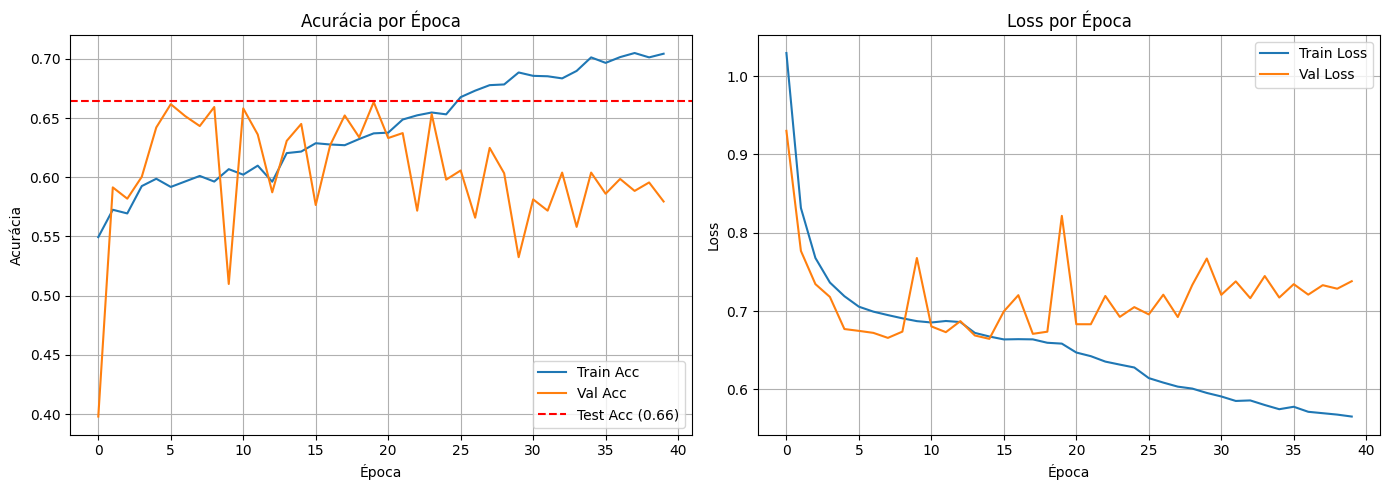

36/36 ━━━━━━━━━━━━━━━━━━━━ 28s 326ms/step


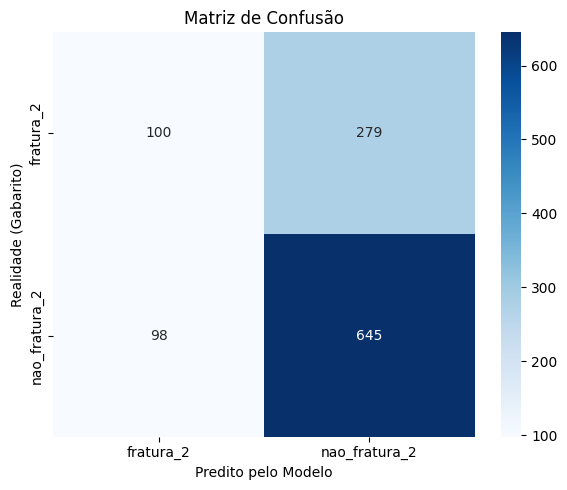

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix


acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Curva de Acurácia
axes[0].plot(acc, label="Train Acc")
axes[0].plot(val_acc, label="Val Acc")
# Supondo que a variável 'accuracy' veio do seu model.evaluate() anterior
axes[0].axhline(y=accuracy, color="r", linestyle="--", label=f"Test Acc ({accuracy:.2f})")
axes[0].set_title("Acurácia por Época")
axes[0].set_xlabel("Época")
axes[0].set_ylabel("Acurácia")
axes[0].legend()
axes[0].grid(True)

# Curva de Loss
axes[1].plot(loss, label="Train Loss")
axes[1].plot(val_loss, label="Val Loss")
axes[1].set_title("Loss por Época")
axes[1].set_xlabel("Época")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig("ct_certo.png", dpi=150)
plt.show()


y_true = np.concatenate([y for x, y in test_dataset], axis=0)
y_pred_probs = modelo.predict(test_dataset)
y_pred = (y_pred_probs > 0.5).astype(int).flatten()
cm = confusion_matrix(y_true, y_pred)
label_names = class_names # Aquela variável que criamos lá em cima!
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=label_names, yticklabels=label_names)
plt.title("Matriz de Confusão")
plt.xlabel("Predito pelo Modelo")
plt.ylabel("Realidade (Gabarito)")
plt.tight_layout()
plt.savefig("matriz_certo.png", dpi=150)
plt.show()

In [ ]:
test_loss, test_acc = model.evaluate(test_generator)

test_ds.reset()
y_pred_prob = model.predict(test_generator)
y_true = test_generator.classes


y_pred = (y_pred_prob > 0.5).astype(int).flatten()
label_names = list(train_generator.class_indices.keys())
print("\n--- Classification Report ---")
print(classification_report(y_true, y_pred, target_names=label_names))